In [1]:
from dotenv import load_dotenv
import os

In [2]:
from langchain_groq import ChatGroq
groq_llm = ChatGroq(model="llama-3.1-8b-instant")

In [3]:
llm_response= groq_llm.invoke("Hello, who are you?")
llm_response.content

"I'm an artificial intelligence model known as a large language model (LLM) or conversational AI. I'm a computer program designed to understand and generate human-like text. I'm here to assist and communicate with you in a helpful and informative way.\n\nI can answer questions, provide information on a wide range of topics, offer suggestions, and even engage in conversation. My goal is to be a useful tool for you, and I'll do my best to provide accurate and helpful responses.\n\nWhat would you like to talk about or ask me today?"

In [4]:
from typing_extensions import TypedDict, Annotated
import operator

In [5]:
from langchain_core.messages import AnyMessage , HumanMessage, AIMessage

In [6]:
# Defining State
class GraphState(TypedDict):
    messages : Annotated[list[AnyMessage], operator.add]

In [7]:
# First Node

def llm_call(state : GraphState) -> dict:
    """Call the LLM using conversation messages and append AI Responses"""
    response = groq_llm.invoke(state["messages"])
    return {
        "messages" :[response]
        #messages" :state['messages'] + [response]
    }

In [8]:
# Second Node
def token_counter(state:GraphState)->dict:
    """Count tokens(simple word count) in the last AI Message"""
    last_msg = state['messages'][-1]
    text = last_msg.content
    token_number = len(text.split())
    Summary = f"Total token number in the generated answer (word count) is {token_number}"

    return {
       "messages" : [AIMessage(content=Summary)]
       # "messages" : state['messages']
    }

Finally, We have to Orchestrate the workflow

In [9]:
# Orchestration -> step by step executing , sequential manner
from langgraph.graph import StateGraph

builder = StateGraph(GraphState)

# adding Nodes

builder.add_node("llm_call", llm_call)
builder.add_node("token_counter",token_counter)

In [10]:
# Add Edges
builder.set_entry_point("llm_call")
builder.add_edge("llm_call","token_counter")
builder.set_finish_point("token_counter")

app=builder.compile()

visualize the Graph

In [11]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

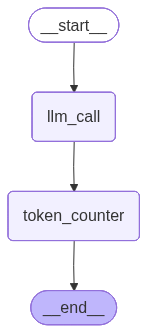

In [12]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [13]:
# Calling entire flow / Graph -> use invoke,astream

In [14]:
result = app.invoke({
    "messages" : [HumanMessage(content="Hi , This is Venkatesh,say hello in detail")]
})

In [15]:
result

{'messages': [HumanMessage(content='Hi , This is Venkatesh,say hello in detail', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Namaste! Hello, my name is Venkatesh, and it's a pleasure to make your acquaintance. I'm a friendly and approachable individual, always eager to engage in meaningful conversations and connections.\n\nAs a warm and welcoming person, I'm here to offer you a big smile and a friendly hello. I'm excited to learn more about you, your interests, and your passions. Whether we're discussing the latest trends, sharing stories, or exploring new ideas, I'm all ears and ready to listen.\n\nSo, take a deep breath, relax, and let's get to know each other better. I'm looking forward to our conversation and building a lasting connection. How are you doing today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 143, 'prompt_tokens': 48, 'total_tokens': 191, 'completion_time': 0.262722429, 'completion_tokens_details': None, 'prom

In [16]:
for M in result['messages']:
    print(type(M).__name__,":", M.content)

HumanMessage : Hi , This is Venkatesh,say hello in detail
AIMessage : Namaste! Hello, my name is Venkatesh, and it's a pleasure to make your acquaintance. I'm a friendly and approachable individual, always eager to engage in meaningful conversations and connections.

As a warm and welcoming person, I'm here to offer you a big smile and a friendly hello. I'm excited to learn more about you, your interests, and your passions. Whether we're discussing the latest trends, sharing stories, or exploring new ideas, I'm all ears and ready to listen.

So, take a deep breath, relax, and let's get to know each other better. I'm looking forward to our conversation and building a lasting connection. How are you doing today?
AIMessage : Total token number in the generated answer (word count) is 108


In [17]:
result = app.invoke({
    "messages" : [HumanMessage(content="Good to hear you ! and Bye Now !")] 
})

In [18]:
for M in result['messages']:
    print(type(M).__name__,":", M.content)

HumanMessage : Good to hear you ! and Bye Now !
AIMessage : It was nice chatting with you, even if it was brief. Have a great day and feel free to come back if you need anything else. Bye for now!
AIMessage : Total token number in the generated answer (word count) is 29


In [19]:
result

{'messages': [HumanMessage(content='Good to hear you ! and Bye Now !', additional_kwargs={}, response_metadata={}),
  AIMessage(content='It was nice chatting with you, even if it was brief. Have a great day and feel free to come back if you need anything else. Bye for now!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 44, 'total_tokens': 78, 'completion_time': 0.036522056, 'completion_tokens_details': None, 'prompt_time': 0.002754565, 'prompt_tokens_details': None, 'queue_time': 0.046996423, 'total_time': 0.039276621}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c64db-b282-7813-8518-67f7fc1d4c40-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 34, 'total_tokens': 78}),
  AIMessage(content='Total token number in the generated answer (word coun

- If you use [response], the old user message "Hello" is discarded — only the AI’s reply remains.
- If you want to keep the conversation history, you should append instead

return {
    "messages": state["messages"] + [response]
}


Tool Calling 

In [20]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [21]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5, doc_content_chars_max=500)

In [22]:
wiki_tool =WikipediaQueryRun(api_wrapper=api_wrapper)

In [23]:
wiki_tool.run({"query":"Transformers in Large language models"})

'Page: Large language model\nSummary: A large language model (LLM) is a language model trained with self-supervised machine learning on a vast amount of text, designed for natural language processing tasks, especially language generation. The largest and most capable LLMs are generative pre-trained transformers (GPTs) that provide the core capabilities of modern chatbots. LLMs can be fine-tuned for specific tasks or guided by prompt engineering. These models acquire predictive power regarding synt'

In [24]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults

In [25]:
tool = TavilySearchResults()
tavily_tool = tool.invoke({"query":"How is the future of LLM?"})
tavily_tool

C:\Users\Venkatesh\AppData\Local\Temp\ipykernel_2200\1476877466.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults()


[{'title': 'Future of Large Language Models - GeeksforGeeks',
  'url': 'https://www.geeksforgeeks.org/machine-learning/future-of-large-language-models/',
  'content': "## Future Prospects and Developments\n\nSeeing the demand and efficiency of LLM, the field is expected to introduce more advancements in the future. This field promises immense development shortly across domains with thorough research and experimentation. Let us explore the potential future trends in Large Language Models. [...] ## Emerging Trends in LLMs\n\nThe field of large language Models (LLMs) is evolving and consistently pushing its limitations with emerging advancements and trends. Let's look closely at the emerging trends in the LLM space. [...] In the last few years, the development of artificial intelligence has been in significant demand, with the emergence of Large Language Models (LLMs). This streamlined model entails advanced machine learning methods, has transformed natural language procedures, and is exp

In [26]:
from langchain_community.tools import DuckDuckGoSearchResults
search = DuckDuckGoSearchResults()

In [27]:
duckduck_tool = search.invoke("what's latest news on LLM?")

Impersonate 'edge_101' does not exist, using 'random'


In [28]:
# BingSearch , googleserpai API

In [29]:
from langchain_community.tools import YouTubeSearchTool
youtube_tool = YouTubeSearchTool()

In [30]:
youtube_tool.name

'youtube_search'

In [31]:
youtube_tool.run("LLM")

"['https://www.youtube.com/watch?v=5sLYAQS9sWQ&pp=ygUDTExN0gcJCYcKAYcqIYzv', 'https://www.youtube.com/watch?v=67_aMPDk2zw&pp=ygUDTExN']"

In [32]:
# A Simple Method , can not call run or Invoke method
def multiply(a:int , b:int)-> int:
    return a *b

multiply(10,20)

200

In [33]:
# Use @tool decorator
from langchain.tools import tool

@tool
def multiply(y:int , z:int)->any:

    """Y : takes the integer input
       z : take the integer input
       return the multiplied value anytype"""
    
    return y*z

In [34]:
multiply.invoke({"y":50,"z":40})

2000

In [35]:
print(multiply.name)
print(multiply.description)
print(multiply.args)

multiply
Y : takes the integer input
       z : take the integer input
       return the multiplied value anytype
{'y': {'title': 'Y', 'type': 'integer'}, 'z': {'title': 'Z', 'type': 'integer'}}


In [36]:
@tool
def length_word(word:str)-> int:
    """it is a tool to count the length of the words"""
    return len(word)

In [37]:
length_word.invoke("hello large language models  and tool calling with Decorator")

60

In [38]:
length_word.args

{'word': {'title': 'Word', 'type': 'string'}}

In [39]:
import yfinance as yf

In [40]:
@tool
def get_Stock_price(ticker:str)-> str:

    """this is tool to get the stock price using yfinance"""
    try:

        stock = yf.Ticker(ticker) # ticker name of the stock

        # Get last 1 day historical data

        data = stock.history(period ="1d")

        if data.empty:
            return f"No data found for ticker {ticker} . please check the symbol"
        
        latest_close = data["Close"].iloc[-1]

        currency = stock.info.get("currency","")

        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£",
            "JPY": "¥",
            "CNY": "¥",
            "AUD": "A$",
            "CAD": "C$",
            "CHF": "CHF",
            "KRW": "₩",
            "RUB": "₽",
            "TRY": "₺",
            "BTC": "₿"
        }

        symbol =symbol_map.get(currency,"")
        currency_text = currency if currency else ""

        if symbol:
            return f"the last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}"
        else:
            return f"the last closing price of {ticker.upper()} was {latest_close:.2f}{currency_text}"


    except Exception as e:
        return f"An Error occured while fetching stock data : {str(e)}"

In [41]:
get_Stock_price.invoke("TCS.NS")

'the last closing price of TCS.NS was ₹2697.90'

In [42]:
get_Stock_price.invoke("CTS")

'the last closing price of CTS was $57.46'

In [43]:
get_Stock_price.invoke("AAPL")

'the last closing price of AAPL was $255.78'

In [44]:
get_Stock_price.invoke("TSLA")

'the last closing price of TSLA was $417.44'

In [45]:
get_Stock_price.invoke("HDFC")

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: HDFC"}}}
$HDFC: possibly delisted; no price data found  (period=1d) (Yahoo error = "No data found, symbol may be delisted")


'No data found for ticker HDFC . please check the symbol'

How LLM's will decide which tool needs to be call

In [46]:
# Define List of all tools - in List
tools =[get_Stock_price,multiply,length_word,wiki_tool]

In [47]:
# bind with the LLM
llm_with_tools = groq_llm.bind_tools(tools)

In [48]:
result = llm_with_tools.invoke("what is the stock price of TCS.NS?")

In [49]:
result

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'zm1frbt66', 'function': {'arguments': '{"ticker":"TCS.NS"}', 'name': 'get_Stock_price'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 507, 'total_tokens': 525, 'completion_time': 0.050323748, 'completion_tokens_details': None, 'prompt_time': 0.038597911, 'prompt_tokens_details': None, 'queue_time': 0.047000362, 'total_time': 0.088921659}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_1151d4f23c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c64dc-2868-7091-8a1b-d72c78645c2f-0', tool_calls=[{'name': 'get_Stock_price', 'args': {'ticker': 'TCS.NS'}, 'id': 'zm1frbt66', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 507, 'output_tokens': 18, 'total_tokens': 525})

In [50]:
result.tool_calls

[{'name': 'get_Stock_price',
  'args': {'ticker': 'TCS.NS'},
  'id': 'zm1frbt66',
  'type': 'tool_call'}]

In [51]:
result.content

''

In [52]:
word_length_tool= llm_with_tools.invoke("How many words in the sentence, 'Hello world , this is a test sentence' ")
word_length_tool

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'h8a9f0zws', 'function': {'arguments': '{"word":"Hello world , this is a test sentence"}', 'name': 'length_word'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 514, 'total_tokens': 535, 'completion_time': 0.025707379, 'completion_tokens_details': None, 'prompt_time': 0.03060297, 'prompt_tokens_details': None, 'queue_time': 0.046108882, 'total_time': 0.056310349}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_ff2b098aaf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c64dc-2a37-7840-8bab-08c474f8a0ea-0', tool_calls=[{'name': 'length_word', 'args': {'word': 'Hello world , this is a test sentence'}, 'id': 'h8a9f0zws', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 514, 'output_tokens': 21, 'total_tokens': 535})

In [53]:
word_length_tool.tool_calls

[{'name': 'length_word',
  'args': {'word': 'Hello world , this is a test sentence'},
  'id': 'h8a9f0zws',
  'type': 'tool_call'}]

In [54]:
multiply_tool= llm_with_tools.invoke("what is the multiplication of 2 and 3?")
multiply_tool

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '9xnsaqpbh', 'function': {'arguments': '{"y":2,"z":3}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 507, 'total_tokens': 526, 'completion_time': 0.039517754, 'completion_tokens_details': None, 'prompt_time': 0.071944823, 'prompt_tokens_details': None, 'queue_time': 0.055014236, 'total_time': 0.111462577}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c64dc-2b24-7951-b6af-54ca0c93e9b8-0', tool_calls=[{'name': 'multiply', 'args': {'y': 2, 'z': 3}, 'id': '9xnsaqpbh', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 507, 'output_tokens': 19, 'total_tokens': 526})

In [55]:
multiply_tool.tool_calls

[{'name': 'multiply',
  'args': {'y': 2, 'z': 3},
  'id': '9xnsaqpbh',
  'type': 'tool_call'}]

In [56]:
# Normal scenario, with out tool, LLM giving answer
normal_question= llm_with_tools.invoke("Hi , How are you?")

In [57]:
normal_question

AIMessage(content="I'm functioning properly, thanks for asking. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 502, 'total_tokens': 519, 'completion_time': 0.023724524, 'completion_tokens_details': None, 'prompt_time': 0.030662406, 'prompt_tokens_details': None, 'queue_time': 0.046234634, 'total_time': 0.05438693}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c64dc-2c4f-7603-b95e-ee028426f72c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 502, 'output_tokens': 17, 'total_tokens': 519})

In [58]:
normal_question.tool_calls

[]

In [59]:
tool_calling_question= llm_with_tools.invoke("what was the latest india union budget of India 2026? ")

In [60]:
tool_calling_question.tool_calls

[]

In [61]:
tool_calling_question.content

'<wikipedia>{"query": "India Union Budget 2026"} </function>'

In [62]:
from langchain_core.messages import HumanMessage,SystemMessage
from langgraph.graph import MessagesState,StateGraph,END,START
from langgraph.prebuilt import ToolNode,tools_condition

In [83]:
System_prompt = SystemMessage(content="your a helpful assistant that can use tools to answer questions.")

In [74]:
def function_1(state: MessagesState):
    
    user_question = state['messages']

    input_question = [System_prompt]+user_question

    response = llm_with_tools.invoke(input_question)
    return{
        "messages":[response]
    }


In [75]:
function_2 = ToolNode(tools=tools)

In [76]:
workflow= StateGraph(MessagesState)

workflow .add_node("llm", function_1)
workflow.add_node("tools",function_2)

In [77]:
workflow.add_edge(START,"llm")

In [78]:
workflow.add_conditional_edges("llm",tools_condition,)

In [79]:
workflow.add_edge("tools","llm")

In [80]:
app = workflow.compile()

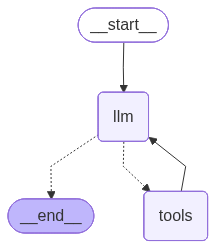

In [72]:
from IPython.display import Image,display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [84]:
result = app.invoke({
    "messages":[HumanMessage(content="What is the price of TCS.NS today?")]
    })

In [85]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the price of TCS.NS today?
================================== Ai Message ==================================
Tool Calls:
  get_Stock_price (ht7gct03z)
 Call ID: ht7gct03z
  Args:
    ticker: TCS.NS
================================= Tool Message =================================
Name: get_Stock_price

the last closing price of TCS.NS was ₹2683.00
================================== Ai Message ==================================

I'm sorry, but I cannot verify the current closing price of TCS.NS as this information is not accessible to me.


In [89]:
result = app.invoke({
    "messages":[HumanMessage(content="what was the latest union budget in india?")]
    })

In [90]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

what was the latest union budget in india?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (hk2jw6abd)
 Call ID: hk2jw6abd
  Args:
    query: Latest Union Budget in India
================================= Tool Message =================================
Name: wikipedia

Page: Union budget of India
Summary: The Union Budget of India, also known as the Annual Financial Statement under Article 112 of the Indian Constitution, is the country's annual financial plan prepared by the Ministry of Finance. It outlines the government's expected revenues, collected by the Department of Revenue, and planned expenditures, managed by the Department of Expenditure. The budget serves as a financial blueprint for the upcoming fiscal year, forecasting economic conditions and alig
================================== Ai Message ==================================
Tool Calls

In [91]:
result = app.invoke({
    "messages":[HumanMessage(content="what is the values of multipying 3590 with 7897? ")]
    })

In [92]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the values of multipying 3590 with 7897? 
================================== Ai Message ==================================
Tool Calls:
  multiply (803haaybz)
 Call ID: 803haaybz
  Args:
    y: 3590
    z: 7897
================================= Tool Message =================================
Name: multiply

28350230
================================== Ai Message ==================================

The result of multiplying 3590 with 7897 is 28350230.


In [93]:
result = app.invoke({
    "messages":[HumanMessage(content="give me latest news about AI and count the length of the response and multipy the response with 10?")]
    })

In [94]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

give me latest news about AI and count the length of the response and multipy the response with 10?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (7kp6a4q1f)
 Call ID: 7kp6a4q1f
  Args:
    query: latest news on AI
  length_word (tfbpf0fgs)
 Call ID: tfbpf0fgs
  Args:
    word: the latest news on artificial intelligence is that researchers have made significant progress in developing more sophisticated language models and computer vision systems. additionally, ai has been increasingly applied in various industries such as healthcare, finance, and education, leading to improved efficiency and decision-making. however, there are also concerns about the potential risks and challenges associated with the growing use of ai, including job displacement, bias, and cybersecurity threats. overall, the future of ai holds great promise, but it also requires c